<img src="data_copy/images_copy/Escudo_uaustralchile.png" width="150">
<img src="data_copy/images_copy/acustica-color.png" width="200">

# Caracterizar Acústicamente tres tipos de sonidos

- Integrantes: Dafne Angulo 
            - Tomás Araya
            - Antonia Jimenez

- ACUS-099
- Profesor Victor Poblete

---

## Tabla de contenido

- Introducción.
- Objetivos.
- Importaciones Librerias.
- Audios.
- Frecuencias de muestreo.
- Pistas de audio.
- Visualizar forma de ondas de las pistas. 
- Comparar sus duraciones.
- FFT.
- DFT.
- STFT.
- FFT versus STFT.
- Aplicación de la FFT a nuestras pistas.
- Espectograma de una pista individual.
- Conclusión.
---

## Introducción

 La Transformada Rápida de Fourier (FFT) es una herramienta que permite transformar una señal desde el dominio del tiempo al dominio de la frecuencia. Gracias a ella es posible identificar qué frecuencias están presentes en una señal, pero no determina en qué instante de tiempo aparece cada una de ellas. Para superar esta limitación se utiliza la Transformada de Fourier de Tiempo Corto (STFT), que divide la señal en pequeños trozos y aplicando una FFT a cada uno de ellos. 

En esta presentación se analizará una señal de audio, aplicando la Transformada Rápida de Fourier (FFT) para estudiar su contenido frecuencial y la Transformada de Fourier de Tiempo Corto (STFT) para visualizar cómo estas frecuencias evolucionan a lo largo del tiempo mediante un espectrograma.

---

## Objetivos

Analizar las señales de audio de biofonía, geofonía y antropofonía mediante la FFT Y STFT

---

## ¿Que tipo de audios vamos a analizar?

- Antropofonia: Son aquellos generados por los seres humanos, ya sea de manera controlada como la música y el lenguaje, o sonidos como el ruido de autos. En nuestro caso vamos a analizar el sonido de una motosierra y de piedras al ser pisadas.

- Geofonia: Se refiere a los sonidos naturales no biológicos que emite la Tierra en un entorno determinado, como la lluvia o el mar. Nosotros vamos a analizar el sonido de un hyrax y de grillos.

- Biofonia: Son el conjunto de sonidos producidos por los seres vivos en su hábitat natural como los animales. Vamos a analizar el sonido de la lluvia y el viento.

---

## Importación de librerias

Las librerias que se van a utilizar son:
- `numpy` para cálculo numérico.
- `matplotlib` para gráficos.
- `librosa` para cargar audio.
- `soundfile` para guardar audio.
- `pathlib` para trabajar con rutas de archivos.


In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
from scipy.signal import welch
from IPython.display import Audio, display


---

## Audios



In [3]:
audio_dir = Path("../data/audio_tracks")

track_files = {
    "Antro1": audio_dir / "Antropofonia_1_(MOTOSIERRA).wav",
    "Antro2": audio_dir / "Antropofonia_2_(PIEDRAS).wav",
    "Bio1": audio_dir / "Biofonia_1_(HYRAX).wav",
    "Bio2": audio_dir / "Biofonia_2_(GRILLOS).wav",
    "Geo1": audio_dir / "Geofonia_1_(lluvia).wav",
    "Geo2": audio_dir / "Geofonia_2_(viento).wav",
}

track_files

{'Antro1': WindowsPath('../data/audio_tracks/Antropofonia_1_(MOTOSIERRA).wav'),
 'Antro2': WindowsPath('../data/audio_tracks/Antropofonia_2_(PIEDRAS).wav'),
 'Bio1': WindowsPath('../data/audio_tracks/Biofonia_1_(HYRAX).wav'),
 'Bio2': WindowsPath('../data/audio_tracks/Biofonia_2_(GRILLOS).wav'),
 'Geo1': WindowsPath('../data/audio_tracks/Geofonia_1_(lluvia).wav'),
 'Geo2': WindowsPath('../data/audio_tracks/Geofonia_2_(viento).wav')}

---

## Frecuencia de muestreo

In [4]:
target_sr = 44100

tracks = {}

for name, path in track_files.items():
    signal, sr = librosa.load(path, sr=target_sr, mono=True)
    tracks[name] = signal

print("Pistas cargadas correctamente.\n")

for name, signal in tracks.items():
    duration = len(signal) / target_sr
    print(f"{name:8s} | samples = {len(signal):9d} | duración = {duration:8.2f} s")

Pistas cargadas correctamente.

Antro1   | samples =   1767424 | duración =    40.08 s
Antro2   | samples =   1770496 | duración =    40.15 s
Bio1     | samples =    782336 | duración =    17.74 s
Bio2     | samples =   2884608 | duración =    65.41 s
Geo1     | samples =    664576 | duración =    15.07 s
Geo2     | samples =   2374656 | duración =    53.85 s


---

## Pistas de Audio

In [5]:
start_time = 0      # seconds
duration_time = 10  # seconds

start_sample = int(start_time * target_sr)
end_sample = int((start_time + duration_time) * target_sr)

for name, signal in tracks.items():
    print(f'Escuchando: {name}')
    display(Audio(signal[start_sample:end_sample], rate=target_sr))

Escuchando: Antro1


Escuchando: Antro2


Escuchando: Bio1


Escuchando: Bio2


Escuchando: Geo1


Escuchando: Geo2


---


## Visualizar forma de ondas de las pistas 

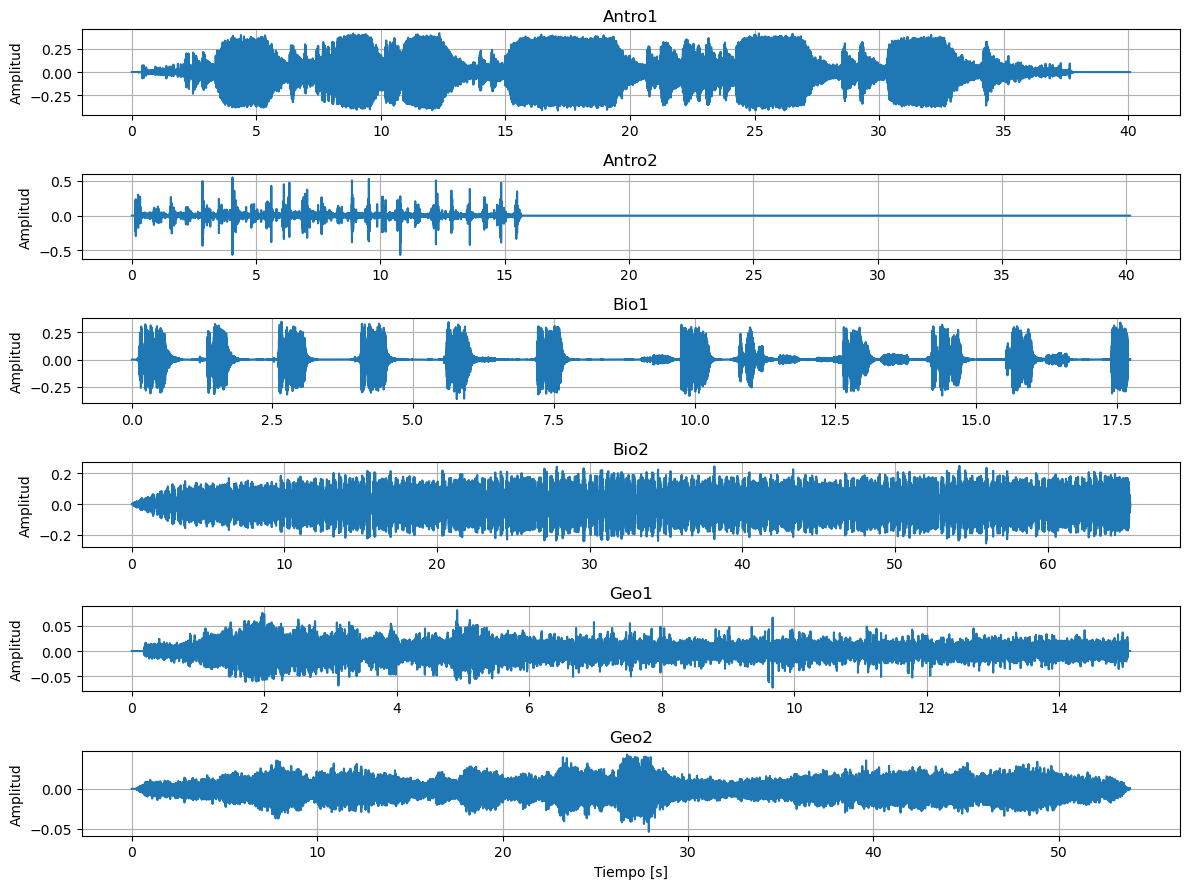

In [6]:
plt.figure(figsize=(12, 9))

for i, (name, signal) in enumerate(tracks.items()):
    t = np.arange(len(signal)) / target_sr
    
    plt.subplot(len(tracks), 1, i + 1)
    plt.plot(t, signal)
    plt.title(name)
    plt.ylabel("Amplitud")
    plt.grid(True)

plt.xlabel("Tiempo [s]")
plt.tight_layout()
plt.show()

---

## Comparar sus duraciones

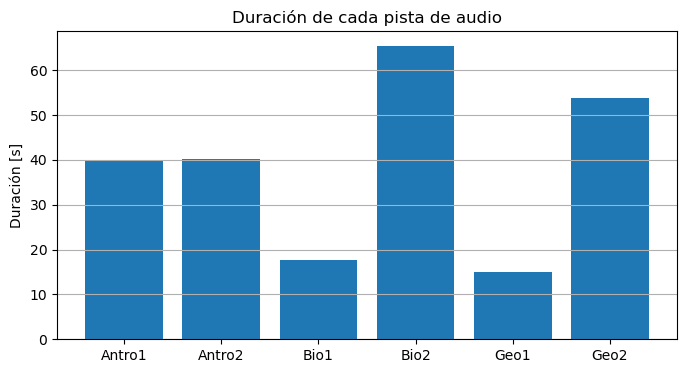

In [7]:
durations = {name: len(signal) / target_sr for name, signal in tracks.items()}

plt.figure(figsize=(8, 4))
plt.bar(durations.keys(), durations.values())
plt.ylabel("Duración [s]")
plt.title("Duración de cada pista de audio")
plt.grid(axis="y")
plt.show()

In [8]:
lengths = {name: len(signal) for name, signal in tracks.items()}

min_length = min(lengths.values())
max_length = max(lengths.values())

print("Pista más corta:", min_length, "muestras")
print("Pista más larga :", max_length, "muestras")
print("Duración más corta:", min_length / target_sr, "s")
print("Duración más larga :", max_length / target_sr, "s")

Pista más corta: 664576 muestras
Pista más larga : 2884608 muestras
Duración más corta: 15.069750566893424 s
Duración más larga : 65.41061224489796 s


 Como las pistas varian considerablemente en duración, recortamos todas para que coincidan con la duracion de la pista más corta.

In [9]:
tracks_trimmed = {}

for name, signal in tracks.items():
    tracks_trimmed[name] = signal[:min_length]

print("Todas las pistas recortadas a", min_length, "muestras.")

Todas las pistas recortadas a 664576 muestras.


---

## FFT

La Transformada de Fourier es una herramienta matemática que permite representar una señal en términos de sus componentes de frecuencia.

En lugar de describir una señal únicamente como una variación en el tiempo:

$
x(t)
$

la Transformada de Fourier permite describirla como una combinación de ondas sinusoidales de distintas frecuencias:

$
X(\omega)
$

donde:

- $x(t)$ representa la señal en el dominio del tiempo,
- $X(\omega)$ representa la señal en el dominio de la frecuencia,
- $\omega$ es la frecuencia angular, medida en rad/s.

La Transformada de Fourier **continua** se define como:

$
X(\omega)=\int_{-\infty}^{\infty} x(t)e^{-j\omega t}\,dt
$

y su transformada inversa es:

$
x(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty} X(\omega)e^{j\omega t}\,d\omega
$

Estas dos expresiones indican que una señal puede estudiarse desde dos perspectivas equivalentes:

$
x(t) \longleftrightarrow X(\omega)
$

Es decir:

- en el dominio del tiempo observamos cómo cambia la amplitud de señal,
- en el dominio de la frecuencia observamos qué frecuencias contiene la señal.

Esta idea es central en procesamiento de señales, porque muchos fenómenos físicos se entienden mejor observando su contenido frecuencial.

---

## DFT

En procesamiento digital de señales trabajamos con señales discretas:

$
x[n]
$

En este caso, utilizamos la **Transformada Discreta de Fourier (DFT)**:

$
X[k]=\sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}
$

donde:

- $n$ es el índice temporal,
- $k$ es el índice de frecuencia,
- $N$ es el número de muestras,
- $x[n]$ es la señal en el dominio del tiempo,
- $X[k]$ es la representación de la señal en el dominio de la frecuencia.

Es importante recordar que $X[k]$ es, en general, una cantidad **compleja**:

$
X[k] = \operatorname{Re}\{X[k]\} + j\operatorname{Im}\{X[k]\}
$

Por lo tanto, $X[k]$ contiene información de:

- **magnitud**, que indica cuánto contenido existe en cada componente frecuencial,
- **fase**, que indica cómo está alineada temporalmente esa componente.

La frecuencia real asociada a cada índice $k$ depende de la frecuencia de muestreo $f_s$:

$
f_k = \frac{k}{N}f_s
$

La operación inversa permite recuperar la señal temporal a partir de su representación en frecuencia. Esta se denomina **Transformada Discreta de Fourier Inversa (IDFT)**:

$
x[n]=\frac{1}{N}\sum_{k=0}^{N-1} X[k]e^{j2\pi kn/N}
$

La DFT y la IDFT forman un par de transformadas:

$
x[n] \longleftrightarrow X[k]
$

Esto significa que la señal puede analizarse en el dominio del tiempo o en el dominio de la frecuencia, sin perder información, siempre que se conserve el espectro complejo completo.



La Transformada Discreta de Fourier puede escribirse como una matriz de la forma:

\[
X = W x
\]

donde:

- \(x\) es la señal en el tiempo.
- \(W\) es la matriz de Fourier.
- \(X\) es la señal transformada al dominio de la frecuencia.

Los elementos de la matriz \(W\) son:


$
W_{k,n} = e^{-j 2\pi kn/N}
$

donde:

- \(k\) es el índice de frecuencia.
- \(n\) es el índice de tiempo discreto.
- \(N\) es el número de muestras.




---

## STFT

La **Short-Time Fourier Transform**, o **STFT**, divide la señal en pequeños fragmentos de tiempo.

Luego aplica una FFT a cada fragmento.

El procedimiento es:

1. Tomar una pequeña ventana de la señal.
2. Calcular la FFT de esa ventana.
3. Mover la ventana un poco hacia adelante.
4. Calcular otra FFT.
5. Repetir hasta recorrer toda la señal.

El resultado es una matriz tiempo-frecuencia.

Cada columna representa un instante o fragmento temporal.  
Cada fila representa una frecuencia.



---

## FFT versus STFT

La FFT global entrega un único espectro para toda la señal.

La STFT entrega muchos espectros locales, uno por cada ventana temporal.

| Herramienta | Pregunta que responde | Resultado |
|---|---|---|
| Forma de onda | ¿Cómo cambia la amplitud en el tiempo? | Señal temporal |
| FFT | ¿Qué frecuencias contiene la señal completa? | Espectro global |
| STFT | ¿Qué frecuencias aparecen en cada momento? | Espectrograma |


> La FFT es como una fotografía global del contenido frecuencial.  
> La STFT es como una película tiempo-frecuencia.

## Aplicación FFT a nuestras pistas


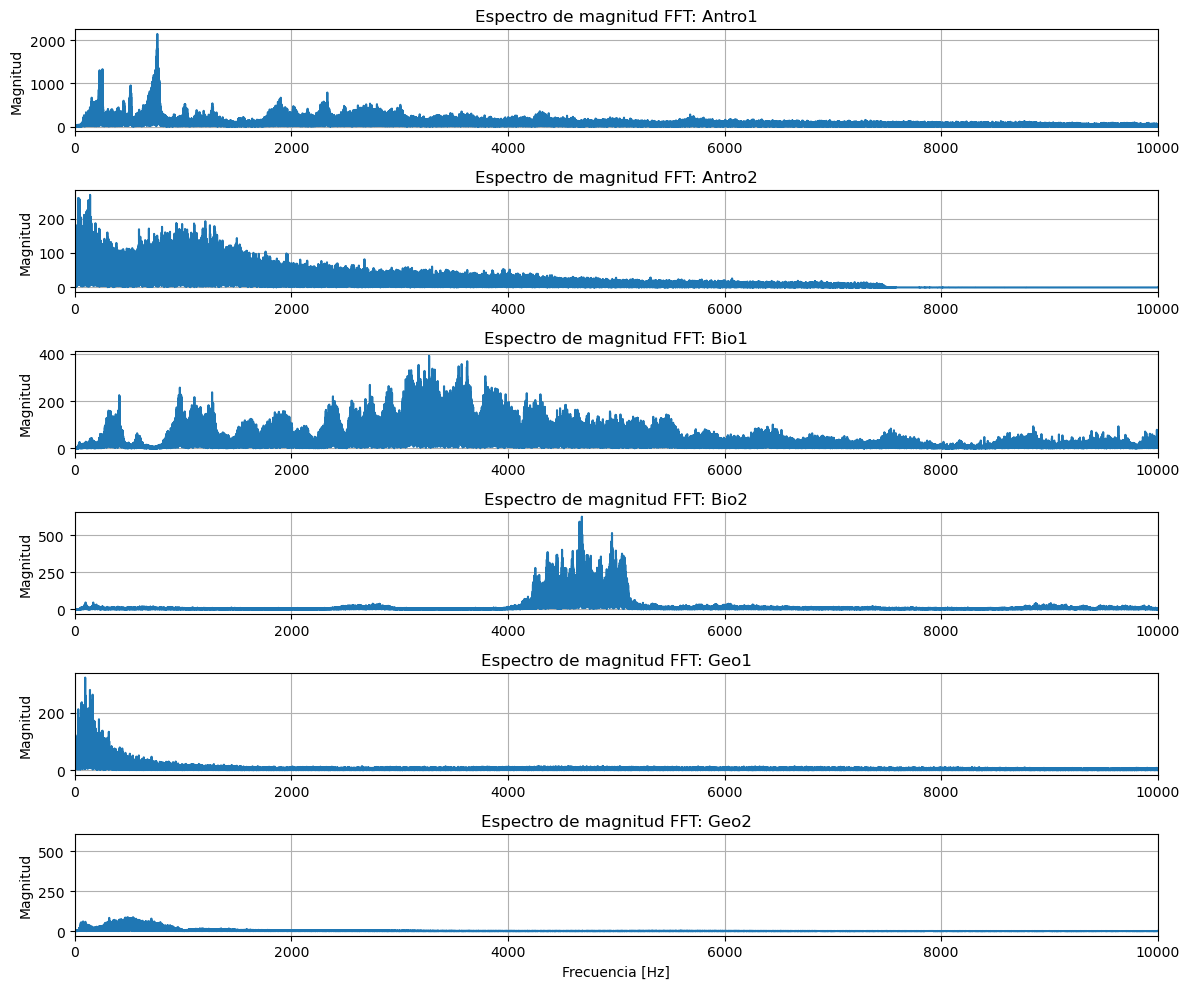

In [13]:
plt.figure(figsize=(12, 10)) 

for i, (name, signal) in enumerate(tracks.items()):

    x_audio = tracks_trimmed[name]
    X = np.fft.fft(x_audio)
    freqs = np.fft.fftfreq(len(x_audio), d=1/target_sr)

    N = len(x_audio)
    positive_freqs = freqs[:N // 2]
    positive_mag = np.abs(X[:N // 2])
    
    plt.subplot(len(tracks), 1, i + 1)
    plt.plot(positive_freqs, positive_mag)
    plt.title(f"Espectro de magnitud FFT: {name}")
    plt.ylabel("Magnitud")
    plt.grid(True)
    plt.xlim(0, 10000)

plt.xlabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()

Podemos, por ejemplo, visualizar los gráficos entre 2000 y 4000 Hz, para compararlos.

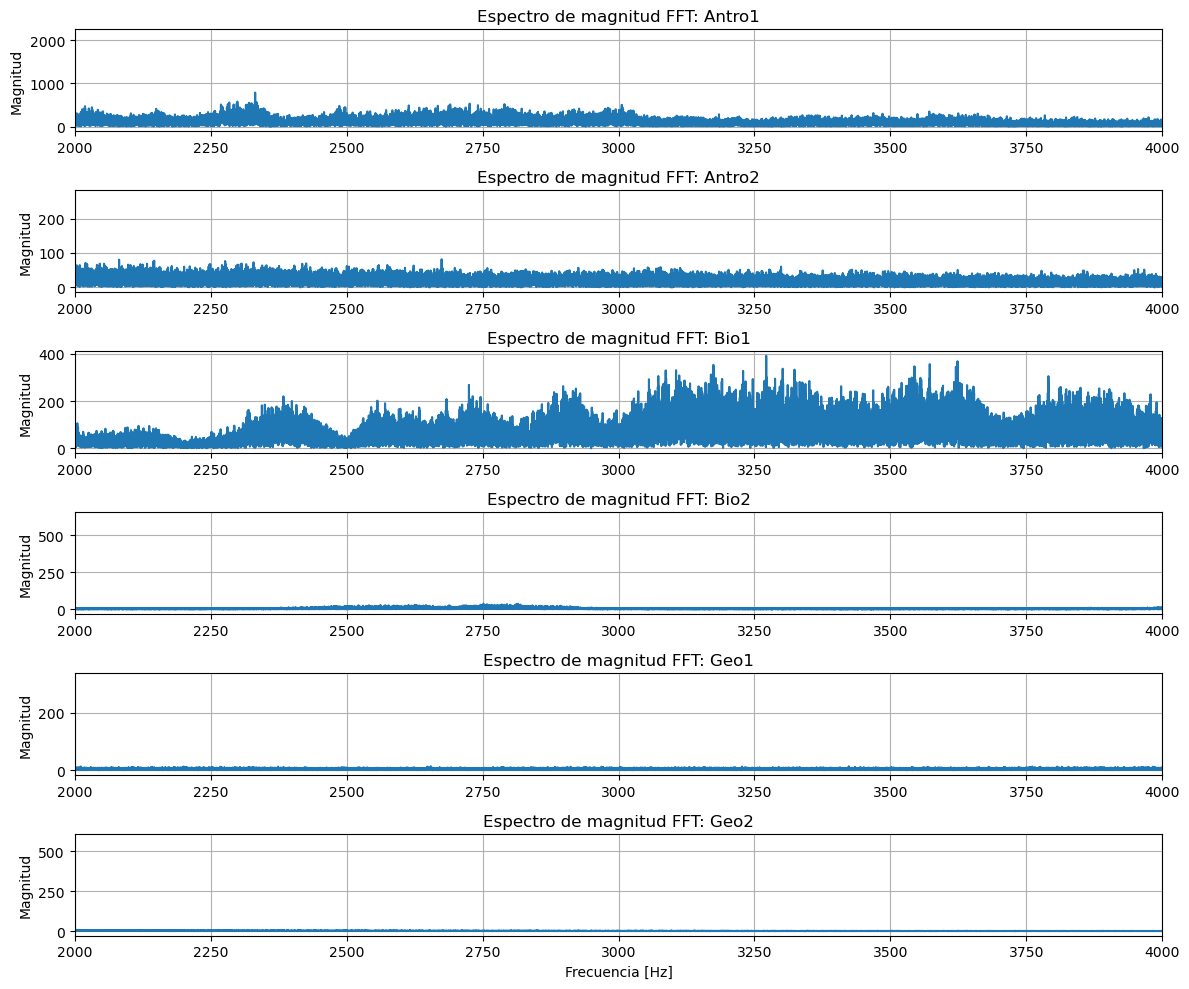

In [14]:
plt.figure(figsize=(12, 10)) 

for i, (name, signal) in enumerate(tracks.items()):

    x_audio = tracks_trimmed[name]
    X = np.fft.fft(x_audio)
    freqs = np.fft.fftfreq(len(x_audio), d=1/target_sr)

    N = len(x_audio)
    positive_freqs = freqs[:N // 2]
    positive_mag = np.abs(X[:N // 2])
    
    plt.subplot(len(tracks), 1, i + 1)
    plt.plot(positive_freqs, positive_mag)
    plt.title(f"Espectro de magnitud FFT: {name}")
    plt.ylabel("Magnitud")
    plt.grid(True)
    plt.xlim(2000, 4000)

plt.xlabel("Frecuencia [Hz]")
plt.tight_layout()
plt.show()

---

## Espectograma de una pista individual

El espectrograma es una imagen tiempo-frecuencia construida a partir de la.

En el espectrograma:

- El eje horizontal representa el tiempo.
- El eje vertical representa la frecuencia.
- El color representa la magnitud o energía.

Las zonas más intensas indican mayor energía en una frecuencia y tiempo determinados.

## Conclusión